Tutorial berikut berdasarkan dokumentasi dari tools DICE:

*   https://github.com/interpretml/DiCE?tab=readme-ov-file
*   https://github.com/interpretml/DiCE/blob/main/docs/source/notebooks/DiCE_getting_started.ipynb
*   https://github.com/interpretml/DiCE/blob/main/docs/source/notebooks/DiCE_multiclass_classification_and_regression.ipynb
*   https://github.com/interpretml/DiCE/blob/main/docs/source/notebooks/DiCE_feature_importances.ipynb
*   https://github.com/interpretml/DiCE/blob/main/docs/source/notebooks/DiCE_model_agnostic_CFs.ipynb

Penjelasan Counterfactual, secara prinsip, bekerja dengan cara menghasilkan sejumlah instances "what-if" (Bagaimana Jika) yang dapat menghasilkan output model tertentu. Untuk lebih memahami, penjelasan counterfactual terhadap sebuah model machine learning $M$ adalah berangkat dari pertanyaan berikut:

>>> Seandainya output dari $M$ adalah $y$ dengan input berupa $x$, apa yang akan terjadi pada output SEANDAINYA input $x$ diganti dengan input $x'$?

Perhatikan bahwa x adalah berupa vektor yang merepresentasikan input. Kumpulan instances "what-if" ini secara formal disebut dengan "Counterfactual examples".

Secara khusus, sebenarnya penjelasan counterfactual lebih menekankan kepada "perubahan apa yang dapat diterapkan pada $x$ sehingga menyebabkan output model menghasilkan nilai yang diinginkan?" Ketika menginspeksi sebuah classifier, sebagai contoh, kita lebih tertarik kepada "perubahan apa yang dapat dilakukan pada $x$ sehingga model memprediksi $x$ dengan kelas yang diharapkan?"

Dalam menentukan tingkat kepentingan dari sebuah fitur $x_i$, DICE menggunakan dua konsep penting berikut:
*  **necessity**: Diberikan sebuah input $x$ dan output dari model $M$, yaitu $y$, sebuah fitur $x_i$ dikatakan "necessary" (diperlukan) untuk menyebabkan model mengeluarkan output $y$ jika mengganti nilai fitur $x_i$ akan mengganti nilai output model, ketika nilai-nilai dari fitur-fitur yang lain (selain $x_i$) dianggap konstan.
*  **sufficiency**: Fitur $x_i$ dikatakan "sufficient" (cukup) untuk menyebabkan model mengeluarkan output $y$ jika **TIDAK MUNGKIN** mengganti nilai output model ketika nilai fitur $x_i$ konstan.

In [ ]:
!pip install dice-ml

In [ ]:
!pip install seaborn

In [ ]:
# Sklearn imports
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

# DiCE imports
import dice_ml
from dice_ml.utils import helpers  # helper functions

Kami menggunakan dataset pendapatan "dewasa" dari UCI Machine Learning Repository (https://archive.ics.uci.edu/ml/datasets/adult). Sebagai demonstrasi, kami mengubah data seperti yang dijelaskan dalam modul dice_ml.utils.helpers.

In [ ]:
dataset = helpers.load_adult_income_dataset()
adult_info = helpers.get_adult_data_info()
adult_info

{'age': 'age',
 'workclass': 'type of industry (Government, Other/Unknown, Private, Self-Employed)',
 'education': 'education level (Assoc, Bachelors, Doctorate, HS-grad, Masters, Prof-school, School, Some-college)',
 'marital_status': 'marital status (Divorced, Married, Separated, Single, Widowed)',
 'occupation': 'occupation (Blue-Collar, Other/Unknown, Professional, Sales, Service, White-Collar)',
 'race': 'white or other race?',
 'gender': 'male or female?',
 'hours_per_week': 'total work hours per week',
 'income': '0 (<=50K) vs 1 (>50K)'}

Kita split dataset menjadi training dan testing.

In [ ]:
target = dataset["income"]
train_dataset, test_dataset, y_train, y_test = train_test_split(dataset,
                                                                target,
                                                                test_size=0.2,
                                                                random_state=0,
                                                                stratify=target)
x_train = train_dataset.drop('income', axis=1)
x_test = test_dataset.drop('income', axis=1)

In [ ]:
x_test.head()

age      workclass     education marital_status     occupation   race  \
14946   29        Private       HS-grad        Married    Blue-Collar  White   
24228   50  Other/Unknown  Some-college        Married  Other/Unknown  White   
605     50        Private     Bachelors        Married   Professional  White   
6238    41        Private        School        Married    Blue-Collar  White   
25954   28  Other/Unknown         Assoc      Separated  Other/Unknown  White   

       gender  hours_per_week  
14946  Female              38  
24228    Male              40  
605      Male              40  
6238     Male              30  
25954  Female              40

**STEP 1**

Kemudian kita bangun objek data untuk DiCE. Karena fitur kontinu dan diskrit memiliki cara perturbatinya yang berbeda, kami perlu menentukan nama fitur kontinu. DiCE juga membutuhkan nama variabel output yang akan diprediksi oleh model ML.

In [ ]:
d = dice_ml.Data(dataframe=train_dataset, continuous_features=['age', 'hours_per_week'], outcome_name='income')

**STEP 2**

Kita load model ML. DICE mendukung Sklearn, Pytorch, dan TF. Variabel backend di bawah menunjukkan jenis implementasi DiCE yang ingin kami gunakan. Empat backend yang didukung: sklearn, TensorFlow 1.x dengan backend='TF1', Tensorflow 2.x dengan backend='TF2', dan PyTorch dengan backend='PYT'.

Di bawah ini kami menunjukkan penggunaan model klasifikasi terlatih menggunakan sklearn.

In [ ]:
numerical = ["age", "hours_per_week"]
categorical = x_train.columns.difference(numerical)

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

transformations = ColumnTransformer(
    transformers=[('cat', categorical_transformer, categorical)])

clf = Pipeline(steps=[('preprocessor', transformations),
                      ('classifier', RandomForestClassifier())])
model = clf.fit(x_train, y_train)

In [ ]:
# prediction
model.predict(x_test)

array([0, 0, 1, ..., 0, 0, 0])

**STEP 3**

Saatnya kita hasilkan Counterfactual Examples ("what-if" datapoints) untuk membantu menjelaskan model.

Saatnya, menginisialisasi DiCE explainer, yang membutuhkan dataset dan model. DiCE memberikan penjelasan lokal untuk model m dan membutuhkan input kueri yang hasilnya perlu dijelaskan.

In [ ]:
# Using sklearn backend
m = dice_ml.Model(model=model, backend="sklearn")

# Using method=random for generating CFs
exp = dice_ml.Dice(d, m, method="random")

Argumen pertama dari metode **generate_counterfactuals** adalah instance kueri di mana counterfactuals diinginkan. Ini bisa berupa dataframe dengan satu atau lebih baris.

Diketahui input kueri, kita sekarang dapat menghasilkan penjelasan counterfactual untuk menunjukkan "perturbed input" dari input asli di mana model ML mengeluarkan kelas 1 (income tinggi). Kolom terakhir menunjukkan output dari pengklasifikasi: income-output >= 0.5 adalah kelas 1 dan income-output < 0.5 adalah kelas 0.

In [ ]:
# Di bawah ini kami menyediakan input sampel (x_test[0:1]) yang hasilnya adalah 0 (input rendah)
# sesuai dengan objek model ML m.

e1 = exp.generate_counterfactuals(x_test[0:1], total_CFs=5, desired_class="opposite")

In [ ]:
# Parameter show_only_changes menyorot perubahan dari instance kueri.
# Jika kita ingin melihat nilai fitur lengkap untuk counterfactuals, atur ke False.
e1.visualize_as_dataframe(show_only_changes=True)

Query instance (original outcome : 0)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,29,Private,HS-grad,Married,Blue-Collar,White,Female,38,0



Diverse Counterfactual set (new outcome: 1)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,-,-,Assoc,-,White-Collar,-,-,-,1
1,-,-,Prof-school,-,-,-,Male,-,1
2,-,Other/Unknown,-,-,Professional,-,-,-,1
3,-,Government,-,-,Professional,-,-,-,1


Apakah fitur "Education" necessary untuk test instence nomor 3?

In [ ]:
e2 = exp.generate_counterfactuals(x_test[2:3],
                                  total_CFs=2,
                                  desired_class="opposite",
                                  features_to_vary=["education"]
                                  )
e2.visualize_as_dataframe(show_only_changes=True)

Query instance (original outcome : 1)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,50,Private,Bachelors,Married,Professional,White,Male,40,1



Diverse Counterfactual set (new outcome: 0)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,-,-,School,-,-,-,-,-,0
1,-,-,HS-grad,-,-,-,-,-,0


Anda dapat mencoba menghasilkan penjelasan counterfactual untuk contoh lain menggunakan kode yang sama.
Juga dimungkinkan untuk membatasi fitur yang bervariasi saat menghasilkan counterfactuals, dan untuk menentukan rentang fitur yang diizinkan di mana counterfactual harus dihasilkan.

In [ ]:
# Diganti, yaitu hanya age dan education
e3 = exp.generate_counterfactuals(x_test[0:1],
                                  total_CFs=5,
                                  desired_class="opposite",
                                  features_to_vary=["education", "occupation"]
                                  )
e3.visualize_as_dataframe(show_only_changes=True)

Query instance (original outcome : 0)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,29,Private,HS-grad,Married,Blue-Collar,White,Female,38,0



Diverse Counterfactual set (new outcome: 1)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,-,-,Assoc,-,White-Collar,-,-,-,1
1,-,-,Masters,-,Sales,-,-,-,1
2,-,-,Masters,-,White-Collar,-,-,-,1
3,-,-,Prof-school,-,White-Collar,-,-,-,1


In [ ]:
# Batasi age diantara [20,30] dan Education antara {'Doctorate', 'Prof-school'}.
e4 = exp.generate_counterfactuals(x_test[0:1],
                                  total_CFs=2,
                                  desired_class="opposite",
                                  permitted_range={'age': [20, 30], 'education': ['Doctorate', 'Prof-school']})
e4.visualize_as_dataframe(show_only_changes=True)

Query instance (original outcome : 0)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,29,Private,HS-grad,Married,Blue-Collar,White,Female,38,0



Diverse Counterfactual set (new outcome: 1)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,-,Self-Employed,-,-,White-Collar,-,-,-,1
1,-,-,Doctorate,-,White-Collar,-,-,-,1


**STEP 4: Feature Attributions**

DICE dapat digunakan untuk menghasilkan feature importance score menggunakan summary dari counterfactual examples yang sudah dihasilkan. Secara intuitif, sebuah fitur yang sering berubah ketika menghasilkan counterfactual examples untuk sebuah input x adalah fitur yang penting (lokal) yang telah mempengaruhi prediksi model terhadap input x. Dengan kata lain, kriteria "necessity" digunakan untuk penjelasan model:

>>  is the feature value necessary for the given model output?

In [ ]:
# Local feature importance scores, misal untuk input x_test[20]

query_instance = x_test[:20] #all
l_imp = exp.local_feature_importance(query_instance, total_CFs=10)

print(l_imp.local_importance)

[{'education': 0.8, 'occupation': 0.6, 'workclass': 0.4, 'marital_status': 0.1, 'gender': 0.1, 'race': 0.0, 'age': 0.0, 'hours_per_week': 0.0}, {'race': 0.5, 'education': 0.4, 'hours_per_week': 0.4, 'workclass': 0.3, 'occupation': 0.3, 'age': 0.1, 'marital_status': 0.0, 'gender': 0.0}, {'marital_status': 0.6, 'education': 0.4, 'workclass': 0.3, 'occupation': 0.3, 'race': 0.1, 'age': 0.1, 'hours_per_week': 0.1, 'gender': 0.0}, {'education': 0.8, 'hours_per_week': 0.3, 'workclass': 0.2, 'occupation': 0.2, 'race': 0.2, 'marital_status': 0.1, 'age': 0.1, 'gender': 0.0}, {'education': 0.6, 'marital_status': 0.6, 'occupation': 0.5, 'workclass': 0.4, 'hours_per_week': 0.3, 'age': 0.1, 'race': 0.0, 'gender': 0.0}, {'education': 0.5, 'occupation': 0.4, 'workclass': 0.3, 'age': 0.3, 'hours_per_week': 0.3, 'gender': 0.1, 'marital_status': 0.0, 'race': 0.0}, {'education': 1.0, 'age': 0.4, 'hours_per_week': 0.3, 'occupation': 0.1, 'race': 0.1, 'workclass': 0.0, 'marital_status': 0.0, 'gender': 0.0}

In [ ]:
# Global feature importance scores
# A global importance score per feature can be estimated by
# aggregating the scores over individual inputs. The more the inputs,
# the better the estimate for global importance of a feature.

query_instances = x_test[:20]
g_imp = exp.global_feature_importance(query_instances)
print(g_imp.summary_importance)

{'education': 0.675, 'marital_status': 0.305, 'occupation': 0.295, 'hours_per_week': 0.23, 'age': 0.215, 'workclass': 0.165, 'race': 0.135, 'gender': 0.04}


<Axes: xlabel='score', ylabel='feature'>

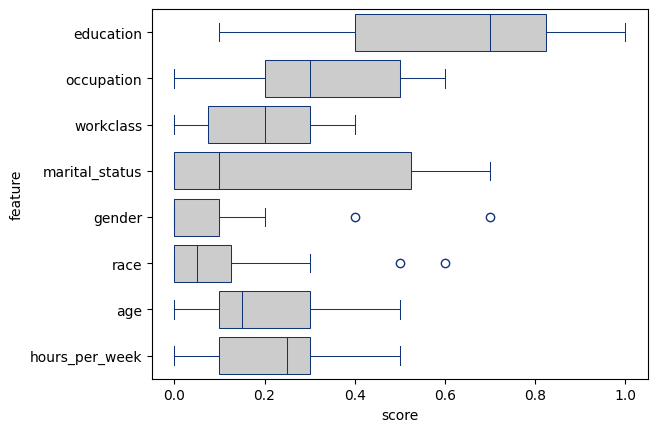

In [ ]:
columns = [key for key in l_imp.local_importance[0].keys()]
feature, score = [], []
for feat_score_dict in l_imp.local_importance:
  for col in columns:
    feature.append(col)
    score.append(feat_score_dict[col])
df_imp = pd.DataFrame({"feature": feature, "score": score})
#so.Plot(df_imp, "score", "feature").add(so.Dots(), so.Jitter(.05))
sns.boxplot(data=df_imp, x="score", y="feature", color=".8", linecolor="#137", linewidth=.75)